# Содержание

[Описание проекта](#Описание_проекта)

[Загрузка библиотек](#Загрузка_библиотек)

[Шаг 1. Загрузка данных и ознакомление](#Шаг_1_Загрузка_данных_и_ознакомление)

[Шаг 2. Лемматизация](#Шаг_2_Лемматизация)

[Шаг 3. Обучение моделей](#Шаг_3_Обучение_моделей)

[Шаг 4. Итоговый вывод](#Шаг_4_Итоговый_вывод)

# Описание проекта

**Описание исследования:**

Интернет-магазин «Викишоп» запускает новый сервис. Теперь пользователи могут редактировать и дополнять описания товаров, как в вики-сообществах. То есть клиенты предлагают свои правки и комментируют изменения других. Магазину нужен инструмент, который будет искать токсичные комментарии и отправлять их на модерацию. 

**Цель исследования:**

Создание модели для классификации комментариев на позитивные и негативные (метрика качества F1 не меньше 0.75).

**Описание данных**

Данные находятся в файле "toxic_comments.csv". Столбец "text" содержит текст комментария, а "toxic" — целевой признак.

# Загрузка библиотек

In [4]:
#!pip install transformers -q
#!pip install torch -q
#!pip uninstall -y typing_extensions
#!pip install typing_extensions==4.11.0

In [5]:
import os
import re

import matplotlib.pyplot as plt
import pandas as pd
import time

import nltk
from nltk import pos_tag, word_tokenize
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import f1_score, make_scorer
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB

</div>

```python
# Скачиваем ресурсы (один раз)

nltk.download('punkt')                      # токенизатор предложений и слов
nltk.download('stopwords')                  # удаление незначимых слов
nltk.download('wordnet')                    # словарь синонимов, антонимов и связей между словами
nltk.download('omw-1.4')                    # дополнение WordNet, помогает учитывать контекст
nltk.download('averaged_perceptron_tagger') # модель для POS-tagging (определения частей речи)
```

<a id='Шаг_1_Загрузка_данных_и_ознакомление'></a>

# Шаг 1. Загрузка данных и ознакомление

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159292 entries, 0 to 159291
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   Unnamed: 0  159292 non-null  int64 
 1   text        159292 non-null  object
 2   toxic       159292 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 3.6+ MB




,Unnamed: 0,text,toxic
0,0,Explanation\nWhy the edits made under my usern...,0
1,1,D'aww! He matches this background colour I'm s...,0
2,2,"Hey man, I'm really not trying to edit war. It...",0
3,3,"""\nMore\nI can't make any real suggestions on ...",0
4,4,"You, sir, are my hero. Any chance you remember...",0


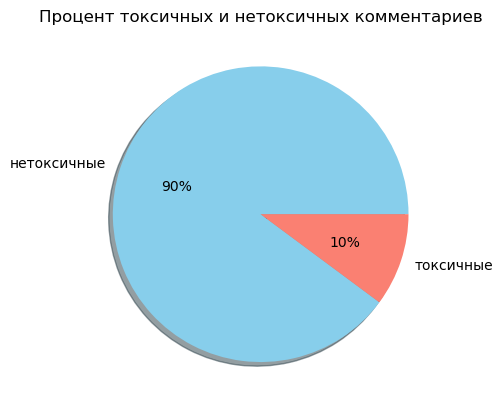

In [9]:
# загружаем данные и выводим общую информацию

df = pd.read_csv('/Users/magomedgakaev/Downloads/toxic_comments.csv')

df.info()
print("\n")
display(df.head())
print("\n")

# Подсчёт количества 0 и 1
value_counts = df['toxic'].value_counts()

# Построение круговой диаграммы
value_counts.plot(
                kind='pie', 
                labels=['нетоксичные', 'токсичные'], 
                autopct='%1.0f%%', 
                colors=['skyblue', 'salmon'],
                shadow=True
                )

plt.title('Процент токсичных и нетоксичных комментариев')
plt.ylabel('')  # убираем подпись оси Y
plt.show()

**Выводы:**

- признак "Unnamed: 0" дублирует функции индекса. Можно от него избавиться;
- в данных выявлен сильный дисбаланс. В дальнейшем, нужно учитывать это при обучении моделей.

In [11]:
# удаляем признак "Unnamed: 0"

df = df.drop('Unnamed: 0', axis=1)

<a id='Шаг_2_Лемматизация'></a>

# Шаг 2. Лемматизация

In [14]:
# Инициализация

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [15]:
# Функция для определения POS-части речи

def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

In [16]:
# Главная функция обработки

def preprocess_text(text):
    
    # 1. Удаление лишних символов
    text = re.sub(r"[^\w\s]", " ", text)
    
    # 2. Приведение к нижнему регистру
    text = text.lower()
    
    # 3. Токенизация
    tokens = word_tokenize(text)
    
    # 4. Удаление стоп-слов
    tokens = [word for word in tokens if word not in stop_words]
    
    # 5. POS-теггинг
    pos_tags = pos_tag(tokens)

    # 6. Лемматизация
    lemmas = [lemmatizer.lemmatize(word, get_wordnet_pos(pos)) for word, pos in pos_tags]
    
    # 7. Объединение в строку
    return ' '.join(lemmas)

<br><br>
Далее необходимо провести лемматизацию текста. Так как после каждого запуска Jupyter Notebook эта операция занимает существенное время, то в целях экономии времени, новый датасет с лемматизированным текстом сохраняется в отдельный файл. Далее, будем работать с этим файлом.

</div>

```python
# проводим лемматизацию текста

df['clean_text'] = df['text'].apply(preprocess_text)
```

In [19]:
# сохраняем датасет с лемматизированным текстом в отдельный файл

if os.path.exists("processed_tweets.pkl"):
    df = pd.read_pickle("processed_tweets.pkl")
    print("Загружен готовый файл.")
else:
    df['clean_text'] = df['text'].apply(preprocess_text)
    df.to_pickle("processed_tweets.pkl")
    print("Обработка завершена и сохранена.")

Загружен готовый файл.


In [20]:
# удаляем колонку со старой информацией и выводим финальный результат

df = df.drop('text', axis=1)
df = df[['clean_text', 'toxic']]

df.head()

,clean_text,toxic
0,explanation edits make username hardcore metal...,0
1,aww match background colour seemingly stuck th...,0
2,hey man really try edit war guy constantly rem...,0
3,make real suggestion improvement wonder sectio...,0
4,sir hero chance remember page,0


**Выводы:**

- удалены лишние символы;
- текст приведен к нижнему регистру;
- удалены стоп-слова;
- учтены части речи в тексте;
- проведена лемматизация и объединение.

<a id='Шаг_3_Обучение_моделей'></a>

# Шаг 3. Обучение моделей

В качестве метода построения языковых представлений выберем **TF-IDF**, так как из-за ограничений в мощностях, нет возможности использовать нейросетевой способ построения языковых представлений (BERT).

In [25]:
# Векторизация

tfidf = TfidfVectorizer(max_features=30000, ngram_range=(1, 2))

In [26]:
# Признаки и целевая переменная

X = tfidf.fit_transform(df['clean_text'])
y = df['toxic']

In [27]:
# Настройка метрики F1

f1 = make_scorer(f1_score, average='macro')  # 'macro' — если классы несбалансированы

Так задача сводится к бинарной классификации, то проведем обучение на следующих 4 моделях, которые лучше остальных справляются с этой задачей:

- LogisticRegression;
- RandomForestClassifier;
- LinearSVC;
- MultinomialNB.

In [29]:
# LogisticRegression

start_train = time.time()
logreg = LogisticRegression(max_iter=1000)
#params_logreg = {'C': [0.1, 1, 10]}
params_logreg = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'],
    'class_weight': [None, 'balanced']
}
grid_logreg = GridSearchCV(logreg, params_logreg, scoring='f1', cv=3, n_jobs=-1)
grid_logreg.fit(X, y)
end_train = time.time()
train_time_logreg = end_train - start_train

start_pred = time.time()
y_pred_logreg = grid_logreg.predict(X)
end_pred = time.time()
pred_time_logreg = end_pred - start_pred

In [30]:
# RandomForestClassifier

start_train = time.time()
rf = RandomForestClassifier()
#params_rf = {'n_estimators': [50, 100], 'max_depth': [10, 20]}
params_rf = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'class_weight': [None, 'balanced']
}
grid_rf = GridSearchCV(rf, params_rf, scoring='f1', cv=3, n_jobs=-1)
grid_rf.fit(X, y)
end_train = time.time()
train_time_rf = end_train - start_train

start_pred = time.time()
y_pred_rf = grid_rf.predict(X)
end_pred = time.time()
pred_time_rf = end_pred - start_pred

In [31]:
# LinearSVC

start_train = time.time()
linear_svm = LinearSVC(max_iter=1000)
#params_lsvm = {'C': [0.1, 1, 10], 'class_weight': [None, 'balanced']}
params_lsvm = {
    'C': [0.01, 0.1, 1, 10],
    'class_weight': [None, 'balanced'],
    'max_iter': [1000, 3000]
}
grid_lsvm = GridSearchCV(linear_svm, params_lsvm, scoring='f1', cv=3, n_jobs=-1)
grid_lsvm.fit(X, y)
end_train = time.time()
train_time_lsvm = end_train - start_train

start_pred = time.time()
y_pred_lsvm = grid_lsvm.predict(X)
end_pred = time.time()
pred_time_lsvm = end_pred - start_pred

In [32]:
# MultinomialNB

start_train = time.time()
nb = MultinomialNB()
#params_nb = {'alpha': [0.1, 1.0, 5.0, 10.0], 'fit_prior': [True, False]}
params_nb = {
    'alpha': [0.01, 0.1, 0.5, 1.0, 5.0, 10.0],
    'fit_prior': [True, False]
}
grid_nb = GridSearchCV(nb, params_nb, scoring='f1', cv=3, n_jobs=-1)
grid_nb.fit(X, y)
end_train = time.time()
train_time_nb = end_train - start_train

start_pred = time.time()
y_pred_nb = grid_nb.predict(X)
end_pred = time.time()
pred_time_nb = end_pred - start_pred

In [33]:
# Вывод результатов

print("Logistic Regression — лучший f1:", grid_logreg.best_score_)
print("Лучшие параметры:", grid_logreg.best_params_)
print("Время обучения: {:.2f} сек, время предсказания: {:.2f} сек\n".format(train_time_logreg, pred_time_logreg))

print("Random Forest — лучший f1:", grid_rf.best_score_)
print("Лучшие параметры:", grid_rf.best_params_)
print("Время обучения: {:.2f} сек, время предсказания: {:.2f} сек\n".format(train_time_rf, pred_time_rf))

print("LinearSVC — лучший f1:", grid_lsvm.best_score_)
print("Лучшие параметры:", grid_lsvm.best_params_)
print("Время обучения: {:.2f} сек, время предсказания: {:.2f} сек\n".format(train_time_lsvm, pred_time_lsvm))

print("MultinomialNB — лучший f1:", grid_nb.best_score_)
print("Лучшие параметры:", grid_nb.best_params_)
print("Время обучения: {:.2f} сек, время предсказания: {:.2f} сек".format(train_time_nb, pred_time_nb))

Logistic Regression — лучший f1: 0.7746216900656616
Лучшие параметры: {'C': 1, 'class_weight': None, 'penalty': 'l1', 'solver': 'liblinear'}
Время обучения: 22.91 сек, время предсказания: 0.01 сек

Random Forest — лучший f1: 0.4337753198445495
Лучшие параметры: {'class_weight': 'balanced', 'max_depth': 15, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
Время обучения: 231.01 сек, время предсказания: 1.06 сек

LinearSVC — лучший f1: 0.7746564502762009
Лучшие параметры: {'C': 1, 'class_weight': None, 'max_iter': 1000}
Время обучения: 18.63 сек, время предсказания: 0.01 сек

MultinomialNB — лучший f1: 0.6954099138579335
Лучшие параметры: {'alpha': 0.1, 'fit_prior': True}
Время обучения: 0.76 сек, время предсказания: 0.03 сек


**Выводы:**

Две модели показали практически одинаковые результаты: 
- Logistic Regression (F1=0.77462), время обучения 22.91 сек;
- LinearSVC (F1=0.77465), время обучения 18.63 сек.

С минимальным перевесом вперед вырвалась модель **LinearSVC** с гиперпараметрами:
- **'C': 1** 
- **'class_weight': None**
- **'max_iter': 1000**

Метрика **F1=0.77**.

<a id='Шаг_4_Итоговый_вывод'></a>

# Шаг 4. Итоговый вывод

**Проведена предобработка текста:**

- удалены лишние символы;
- текст приведен к нижнему регистру;
- удалены стоп-слова;
- учтены части речи в тексте;
- проведена лемматизация и объединение.
- после предобработки датафрейм был разделен на обучающую и тестовую выборки, после чего к текстам была применена векторизация TF-IDF

**Так как задача сводилась к бинарной классификации 0 и 1, выбраны следующие модели машинного обучения:**

- LogisticRegression;
- RandomForestClassifier;
- LinearSVC;
- MultinomialNB.

Так как в ходе обработки был выявлен сильный дисбаланс между токсичными и нетоксичными комментариями (10% к 90%), этот факт учитывался при обучении моделей. 

**После обучения получены следующие результаты:**

Две модели показали практически одинаковые результаты:

- Logistic Regression (F1=0.77462), время обучения 22.91 сек;
- LinearSVC (F1=0.77465), время обучения 18.63 сек.

С минимальным перевесом вперед вырвалась модель **LinearSVC** с гиперпараметрами:
- **'C': 1** 
- **'class_weight': None**
- **'max_iter': 1000**

Метрика **F1=0.77**.

Хуже всех оказалась модель Random Forest, у которой F1=0.43 ниже остальных, а время обучения 231 сек. дольше всех.

Показатели моделей могут быть улучшены при более детальном подборе гиперпараметров, однако, это требует более высоких вычислительных мощностей.